In [59]:
# handle table-like data and matrices
import pandas as pd
import numpy as np

# visualisation
import seaborn as sns
import matplotlib.pyplot as plt

# preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# pca
from sklearn.decomposition import PCA

# clustering
from sklearn.cluster import KMeans, AgglomerativeClustering

# evaluations
from sklearn.metrics import silhouette_score
from kneed import KneeLocator

# ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [60]:
df = pd.read_csv("../../datasets/smartcart_customers.csv")

In [61]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


## Handling Missing Values

In [62]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

In [63]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [64]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
Complain               0
Response               0
dtype: int64

In [65]:
# Duplicate Rows

df.duplicated().sum()

np.int64(0)

## Feature Engineering

In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2240 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [67]:
# Extract the "Age" of a customer by the "Year_Birth" indicating the birth year of the respective person.

df['Age'] = 2015 - df['Year_Birth'] 

In [68]:
# Dt_Customer that indicates the date a customer joined the database is not parsed as DateTime

df['Dt_Customer']=pd.to_datetime(df['Dt_Customer'],dayfirst=True)

print(df['Dt_Customer'].max())
print(df['Dt_Customer'].min())

2014-06-29 00:00:00
2012-07-30 00:00:00


In [69]:
# Create New feature Customer_tenure_days

df['Customer_Tenure_days'] = (df['Dt_Customer'].max() - df['Dt_Customer']).dt.days

In [70]:
#Create another feature "Spent" indicating the total amount spent by the customer in various categories.

df['Total_spending'] = df['MntWines']+df['MntFruits']+df['MntMeatProducts']+df['MntFishProducts']+df['MntSweetProducts']+df['MntGoldProds']

In [71]:
# Create a feature "Children" to indicate total children in a household that is, kids and teenagers.

df['Total_Childs'] = df['Kidhome']+df['Teenhome']


In [72]:
# Segmenting education levels in three groups

df['Education'] = df['Education'].replace({'Graduation':'Graduate','PhD':'Postgraduate','Master':'Postgraduate','2n Cycle':'Undergraduate','Basic':'Undergraduate'})

In [73]:
# Create another feature "Living_With" out of "Marital_Status" to extract the living situation of couples

df['Living_With'] = df['Marital_Status'].replace({'Married':'Partner','Together':'Partner','Divorced':'Single','Widow':'Single','Alone':'Single','Absurd':'Single','YOLO':'Single'})

## DROP COLUMNS

In [74]:
df.shape

(2240, 27)

In [75]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_days', 'Total_spending',
       'Total_Childs', 'Living_With'],
      dtype='object')

In [76]:
cols = ['ID','Marital_Status','Year_Birth','Kidhome','Teenhome', 'Dt_Customer']
spending_cols = ['MntWines', 'MntFruits','MntMeatProducts', 'MntFishProducts', 'MntSweetProducts','MntGoldProds']
cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [77]:
df_cleaned.shape

(2240, 15)

In [78]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_Childs,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,58,663,1617,0,Single
1,Graduate,46344.0,38,2,1,1,2,5,0,0,61,113,27,2,Single
2,Graduate,71613.0,26,1,8,2,10,4,0,0,50,312,776,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,31,139,53,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,34,161,422,1,Partner


# Outlier detection

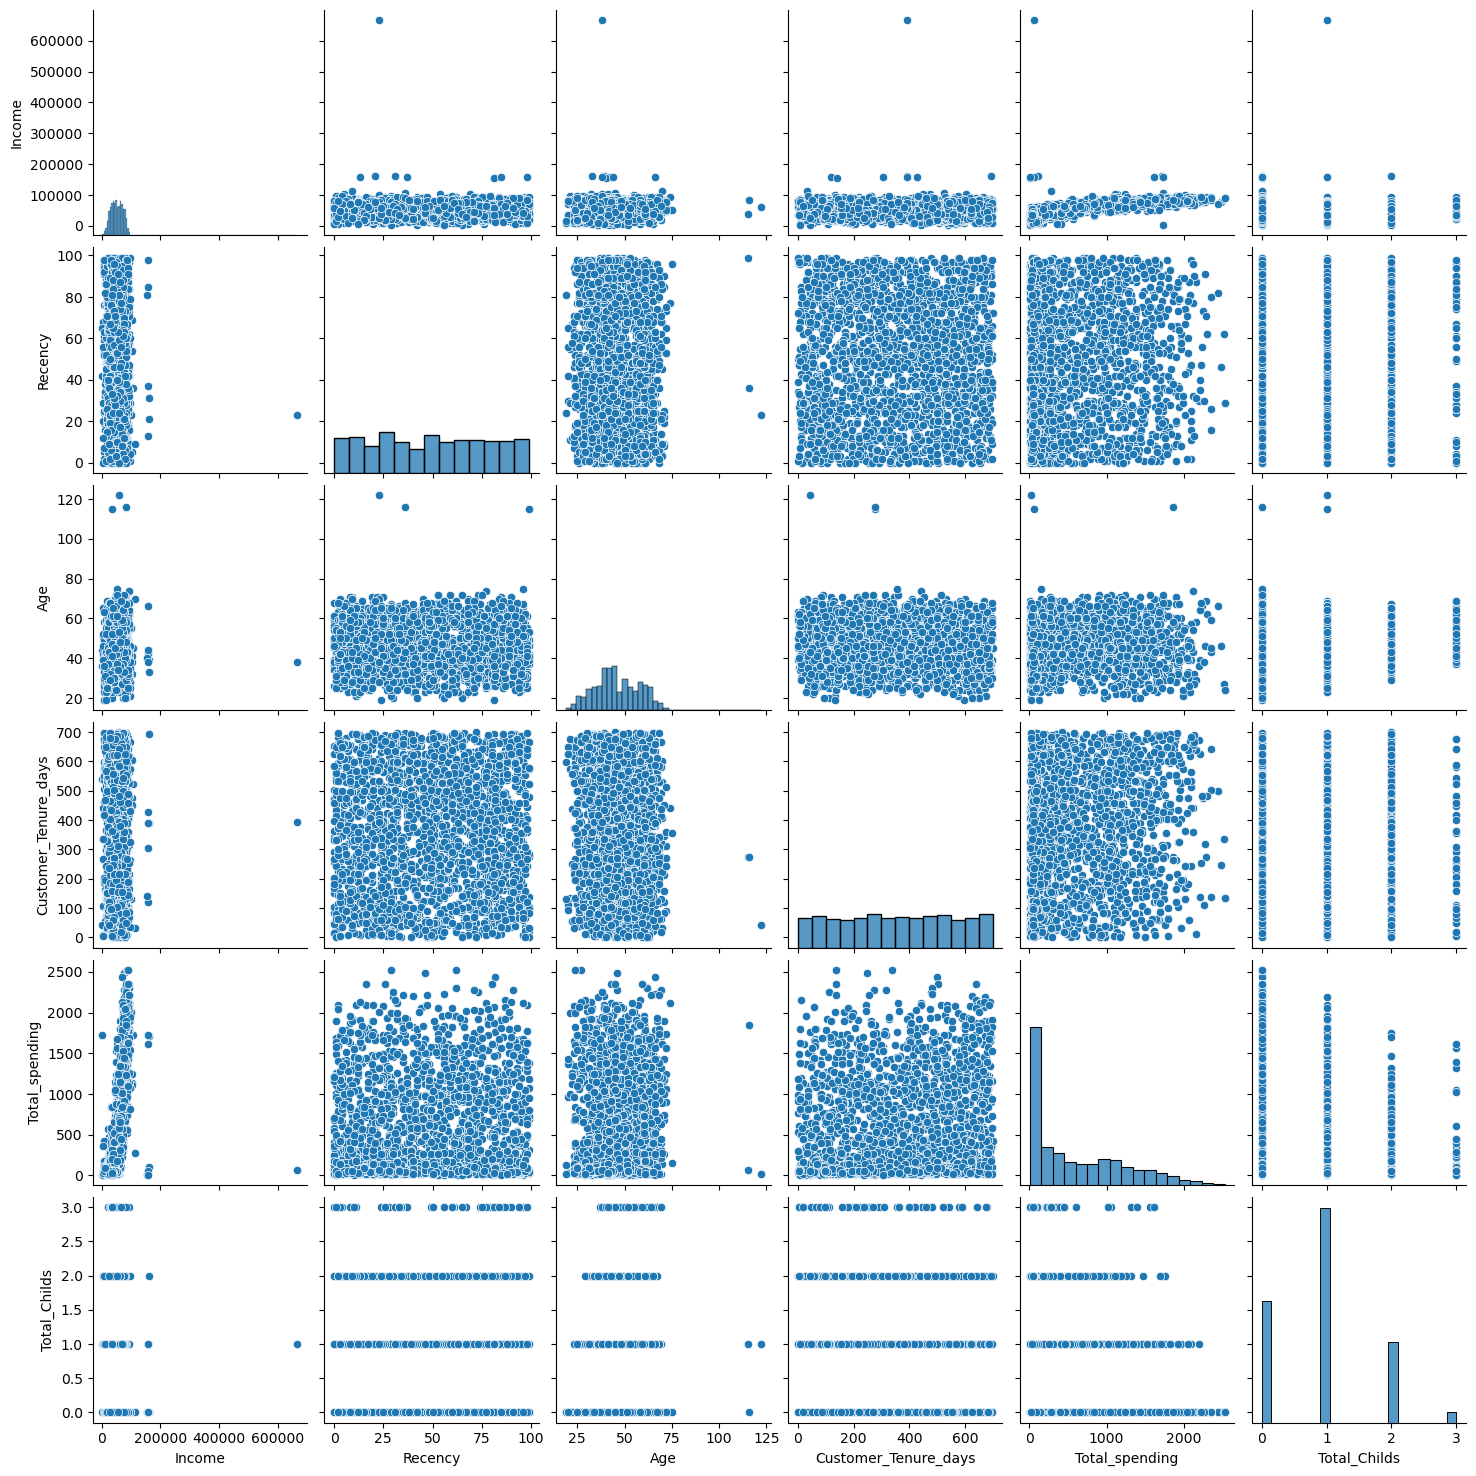

In [79]:
cols = ['Income','Recency','Age','Customer_Tenure_days','Total_spending','Total_Childs']
sns.pairplot(df_cleaned[cols])

In [80]:
print(len(df_cleaned))
df_cleaned = df_cleaned[(df_cleaned['Age']<90)]
df_cleaned = df_cleaned[(df_cleaned['Income']<600000)]
print(len(df_cleaned))

2240
2236


In [81]:
corr = df_cleaned.corr(numeric_only = True)
corr

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_Childs
Income,1.000000,0.007829,-0.107169,0.450584,0.693781,0.628075,-0.646382,-0.027871,0.161121,0.198835,-0.023677,0.789375,-0.340550
Recency,0.007829,1.000000,-0.000638,-0.010776,0.025226,0.000771,-0.021850,0.005361,-0.198781,0.019396,0.024238,0.020842,0.017826
NumDealsPurchases,-0.107169,-0.000638,1.000000,0.233971,-0.008510,0.068418,0.347216,0.003636,0.002017,0.068286,0.218009,-0.064831,0.439682
NumWebPurchases,0.450584,-0.010776,0.233971,1.000000,0.378049,0.502227,-0.056204,-0.013250,0.148390,0.153873,0.191211,0.519948,-0.146429
NumCatalogPurchases,0.693781,0.025226,-0.008510,0.378049,1.000000,0.518788,-0.520376,-0.018304,0.220813,0.125285,0.095836,0.778343,-0.439631
NumStorePurchases,0.628075,0.000771,0.068418,0.502227,0.518788,1.000000,-0.429857,-0.011563,0.038702,0.139237,0.109727,0.675460,-0.321729
NumWebVisitsMonth,-0.646382,-0.021850,0.347216,-0.056204,-0.520376,-0.429857,1.000000,0.020796,-0.004397,-0.117498,0.272105,-0.499909,0.417908
Complain,-0.027871,0.005361,0.003636,-0.013250,-0.018304,-0.011563,0.020796,1.000000,0.000167,0.004450,0.035685,-0.033784,0.031480
Response,0.161121,-0.198781,0.002017,0.148390,0.220813,0.038702,-0.004397,0.000167,1.000000,-0.018557,0.194232,0.265615,-0.169451
Age,0.198835,0.019396,0.068286,0.153873,0.125285,0.139237,-0.117498,0.004450,-0.018557,1.000000,-0.016451,0.113618,0.095512


<Axes: >

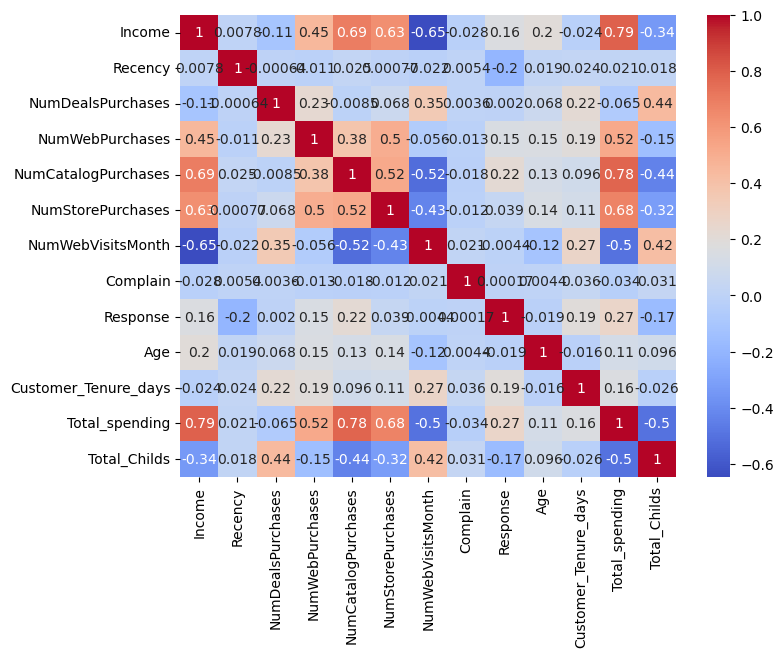

In [82]:
plt.figure(figsize=(8,6))

sns.heatmap(corr,annot=True,cmap='coolwarm')

# Feature Encoding

In [83]:
categorical_cols  = ['Education','Living_With']
ohe = OneHotEncoder()
encoded_cols = ohe.fit_transform(df_cleaned[categorical_cols])

In [84]:
enc_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(categorical_cols), index=df_cleaned.index)

In [85]:
df_encoded = pd.concat([df_cleaned.drop(columns=categorical_cols),enc_df],axis=1)

In [86]:
df_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_Childs,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Partner,Living_With_Single
0,58138.0,58,3,8,10,4,7,0,1,58,663,1617,0,1.0,0.0,0.0,0.0,1.0
1,46344.0,38,2,1,1,2,5,0,0,61,113,27,2,1.0,0.0,0.0,0.0,1.0
2,71613.0,26,1,8,2,10,4,0,0,50,312,776,0,1.0,0.0,0.0,1.0,0.0
3,26646.0,26,2,2,0,4,6,0,0,31,139,53,1,1.0,0.0,0.0,1.0,0.0
4,58293.0,94,5,5,3,6,5,0,0,34,161,422,1,0.0,1.0,0.0,1.0,0.0


# Feature Scaling

In [87]:
X = df_encoded

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [88]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
         0.74204052, -0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
        -1.3476353 ,  1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
         0.74204052, -0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
         0.74204052, -0.74204052]])

# Dimensionality Reduction

In [89]:
pca = PCA(n_components = 3)
X_pca = pca.fit_transform(X_scaled)

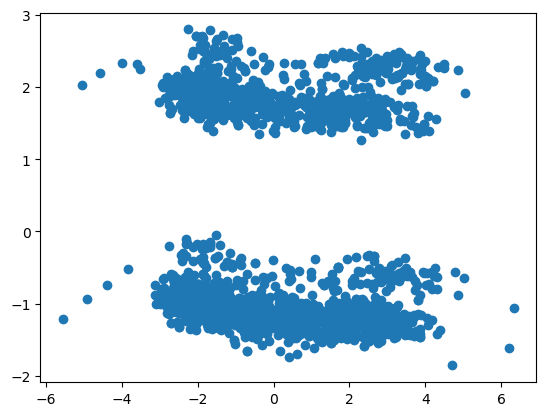

In [90]:
plt.scatter(X_pca[:,0],X_pca[:,1])

In [91]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

Text(0.5, 0.92, '3d projection')

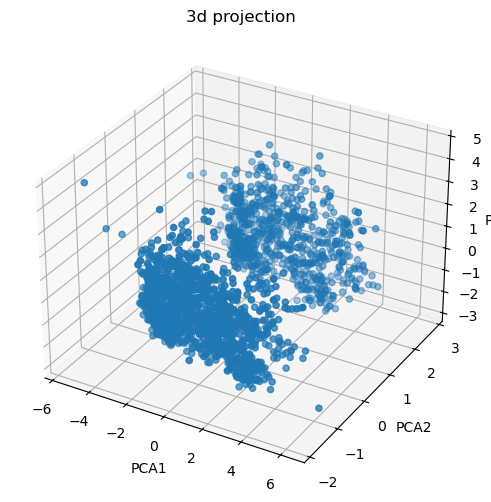

In [92]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.set_zlabel('PCA3')
ax.set_title('3d projection')

# Analyze K Value
## 1.Elbow Method

In [93]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [94]:
knee = KneeLocator(range(1,11),wcss,curve='convex',direction='decreasing')
optimal_k = knee.elbow

In [95]:
print(optimal_k)

4


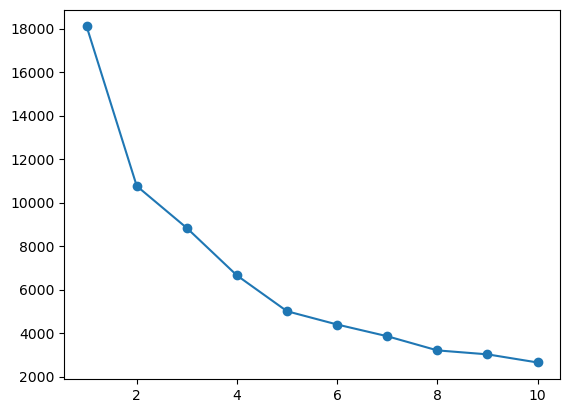

In [96]:
plt.plot(range(1,11),wcss,marker='o')

## 2. Silhouette Score

Text(0, 0.5, 'silhouette score')

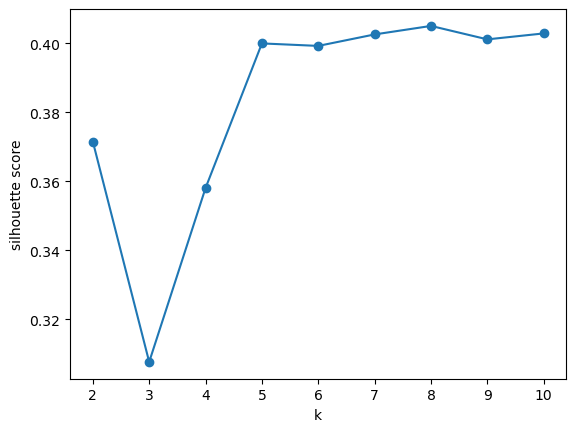

In [97]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel('k')
plt.ylabel('silhouette score')

Text(0, 0.5, 'sihouette_score')

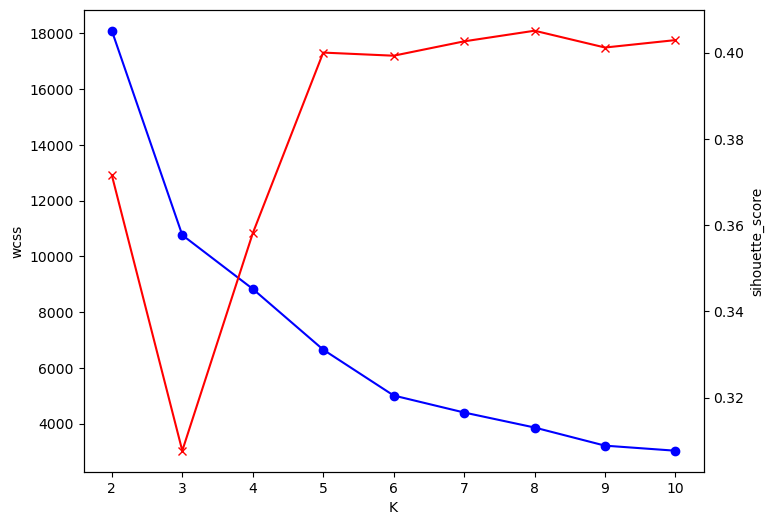

In [98]:
# combined plot
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize=(8,6))

ax1.plot(k_range, wcss[:len(k_range)], marker='o',color='blue')
ax1.set_xlabel("K")
ax1.set_ylabel("wcss")
ax2 = ax1.twinx()
ax2.plot(k_range, scores[:len(k_range)], marker='x',color='red')
ax2.set_ylabel('sihouette_score')

# Clustering

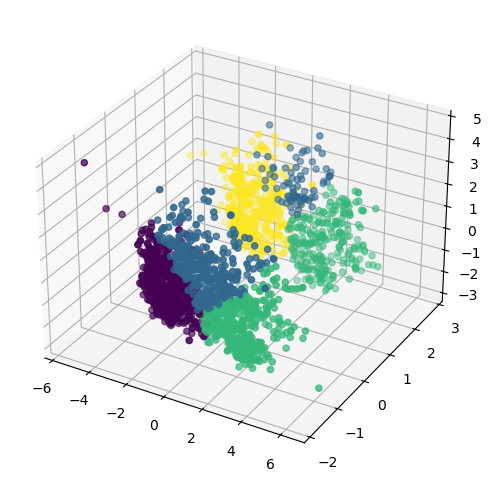

In [99]:
# kmeans

kmeans = KMeans(n_clusters = 4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c= labels_kmeans)

In [100]:
# Agglomerative 

from sklearn.cluster import AgglomerativeClustering

In [101]:
agg_cl = AgglomerativeClustering(n_clusters = 4, linkage='ward')
labels_agg = agg_cl.fit_predict(X_pca)

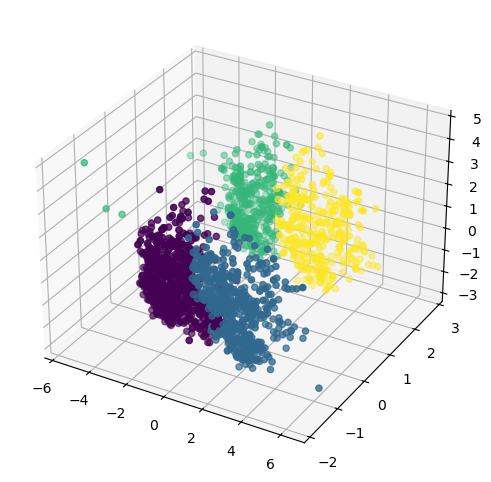

In [102]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(111,projection='3d')

ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

##  Clusters Analysis and Customers Profiling

In [103]:
X['clusters'] = labels_agg
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_days,Total_spending,Total_Childs,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Partner,Living_With_Single,clusters
0,58138.0,58,3,8,10,4,7,0,1,58,663,1617,0,1.0,0.0,0.0,0.0,1.0,3
1,46344.0,38,2,1,1,2,5,0,0,61,113,27,2,1.0,0.0,0.0,0.0,1.0,2
2,71613.0,26,1,8,2,10,4,0,0,50,312,776,0,1.0,0.0,0.0,1.0,0.0,1
3,26646.0,26,2,2,0,4,6,0,0,31,139,53,1,1.0,0.0,0.0,1.0,0.0,0
4,58293.0,94,5,5,3,6,5,0,0,34,161,422,1,0.0,1.0,0.0,1.0,0.0,0


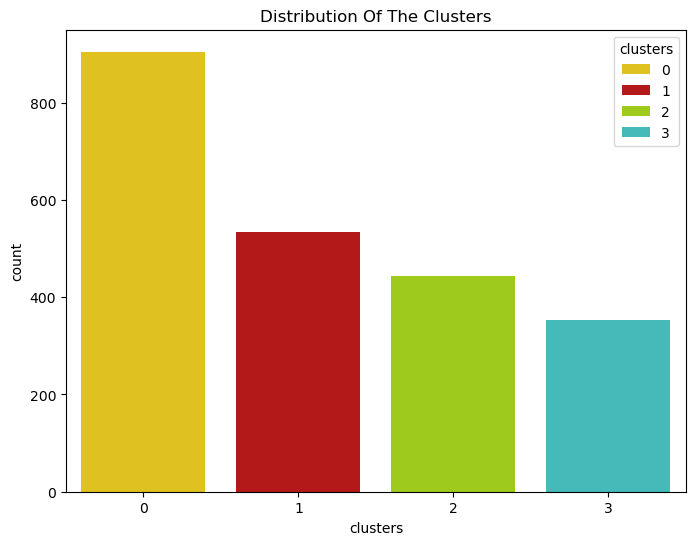

In [104]:
pal = ['gold','#cc0000', '#ace600','#33cccc']
plt.figure(figsize=(8,6))
pl = sns.countplot(x=X['clusters'],palette = pal, hue = X['clusters'])
pl.set_title('Distribution Of The Clusters')
plt.show()

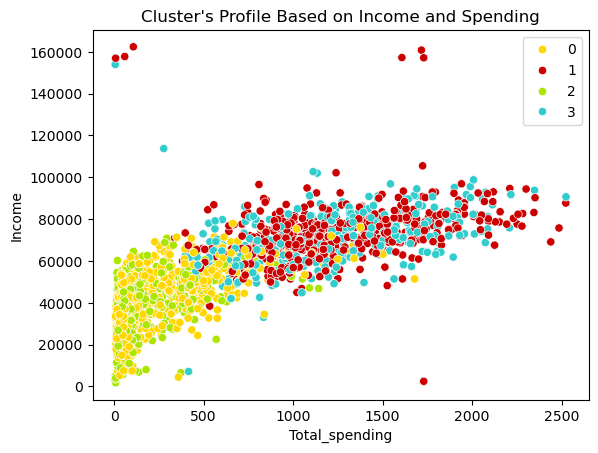

In [105]:
pl = sns.scatterplot(x=X['Total_spending'],y=X['Income'],hue=X['clusters'],palette=pal)
pl.set_title("Cluster's Profile Based on Income and Spending")
plt.legend()

## Income vs spending plot shows the clusters pattern

- group 0: low spending & low income
- group 1: high spending & average income
- group 3: low spending & average income
- group 2: high spending & high income

In [106]:
# Clusters Summary

Clusters_Summary=X.groupby('clusters').mean()

In [107]:
print(Clusters_Summary)

                Income    Recency  NumDealsPurchases  NumWebPurchases  \
clusters                                                                
0         39680.580110  48.914917           2.594475         3.153591   
1         72808.445693  49.202247           1.958801         5.687266   
2         36960.143018  48.319820           2.594595         2.713964   
3         70722.681303  50.504249           1.855524         5.790368   

          NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
clusters                                                                        
0                    0.969061           4.143646           6.307182  0.011050   
1                    5.498127           8.659176           3.580524  0.005618   
2                    0.837838           3.623874           6.659910  0.011261   
3                    5.014164           8.430595           3.728045  0.005666   

          Response        Age  Customer_Tenure_days  Total_spending  \
clu

## **Cluster 0 – Low-value, low-engagement customers**

**Profile:**

    - Low to moderate income 
    - Low purchases across web, store, and catalog
    - High website visits
    - Very low spending 
    - Relatively Younger
    - Mostly partnered
    - More customers with children

**Strategy:**

    - Offer discounts / coupons
    - Retargeting campaigns
    - Personalized product recommendations
    - Engagement emails

## **Cluster 1 – High-value loyal premium customers**

**Profile:**

    - Highest income 
    - High web/store/catalogue purchases 
    - Lower website visits 
    - Highest spending 
    - Older customers
    - Longest tenure
    - Mostly partnered

**Strategy:**

    - Loyalty rewards
    - Premium memberships
    - Exclusive offers
    - Early access to products
    - Personalized premium services

## **Cluster 2 – Browsers with low conversion**

**Profile:**

    - Low income 
    - Low web/store/catalog purchases
    - Highest website visits
    - Lowest spending 
    - Mostly single customers 
    
**Strategy:**

    - Improve website UX
    - Cart abandonment reminders
    - Limited-time offers
    - Simplify checkout process
    - Social proof/reviews

## **Cluster 3 – High-spending digital & store buyers**

**Profile:**

    - High income 
    - High web/store/catalogue purchases 
    - Lower website visits
    - Very high spending 
    - Longest customer tenure 
    - Mostly single

**Strategy:**

    - Upselling / cross-selling
    - New product launches
    - Digital-first campaigns
    - Personalized recommendations
    - Subscription-based offers

In [108]:
# Cluster 1 and 3 are your revenue-driving segments, Cluster 2 has conversion potential, and Cluster 0 needs re-engagement campaigns